<a href="https://colab.research.google.com/github/mirudhulabalaji27-hub/dnd-data-arena-sprint/blob/main/spotify.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

path = '/root/.cache/kagglehub/datasets/meeraajayakumar/spotify-user-behavior-dataset/versions/1/Spotify_data.xlsx'
df = pd.read_excel(path)

plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'DejaVu Sans'
SPOTIFY_GREEN = '#1DB954'
DARK = '#191414'
COLORS = ['#1DB954','#FF6B6B','#4A90D9','#F5A623','#9B59B6','#1ABC9C']

print("✅ Loaded:", df.shape)

✅ Loaded: (520, 20)


In [5]:
# Fill podcast nulls with 'N/A' (these are music-only users — valid data)
pod_cols = ['preffered_premium_plan','fav_pod_genre','preffered_pod_format',
            'pod_host_preference','preffered_pod_duration','pod_variety_satisfaction']
df[pod_cols] = df[pod_cols].fillna('N/A')

# Drop any remaining nulls (tiny, safe)
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

# Clean column names
df.columns = df.columns.str.strip()

# Quick value check on key columns
for col in ['music_time_slot','spotify_subscription_plan','preferred_listening_content',
            'spotify_usage_period','Age','premium_sub_willingness']:
    print(f"\n{col}:\n", df[col].value_counts().to_dict())


music_time_slot:
 {'Night': 311, 'Afternoon': 117, 'Morning': 91}

spotify_subscription_plan:
 {'Free (ad-supported)': 423, 'Premium (paid subscription)': 96}

preferred_listening_content:
 {'Music': 409, 'Podcast': 110}

spotify_usage_period:
 {'More than 2 years': 169, '1 year to 2 years': 140, '6 months to 1 year': 119, 'Less than 6 months': 91}

Age:
 {'20-35': 421, '12-20': 71, '35-60': 23, '6-12': 3, '60+': 1}

premium_sub_willingness:
 {'No': 333, 'Yes': 186}


In [6]:
total_users = len(df)
pct_willing_premium = round((df['premium_sub_willingness'] == 'Yes').mean() * 100, 1)
avg_rating = round(df['music_recc_rating'].mean(), 2)
top_listen_time = df['music_time_slot'].value_counts().idxmax()
pct_music_users = round((df['preferred_listening_content'] == 'Music').mean() * 100, 1)

print("=" * 40)
print(f"📊 Total Users Analyzed   : {total_users}")
print(f"💰 Willing to Go Premium  : {pct_willing_premium}%")
print(f"⭐ Avg Recommendation Rating: {avg_rating} / 5")
print(f"🕐 Peak Listening Time    : {top_listen_time}")
print(f"🎵 Music-First Users      : {pct_music_users}%")
print("=" * 40)

📊 Total Users Analyzed   : 519
💰 Willing to Go Premium  : 35.8%
⭐ Avg Recommendation Rating: 3.5 / 5
🕐 Peak Listening Time    : Night
🎵 Music-First Users      : 78.8%


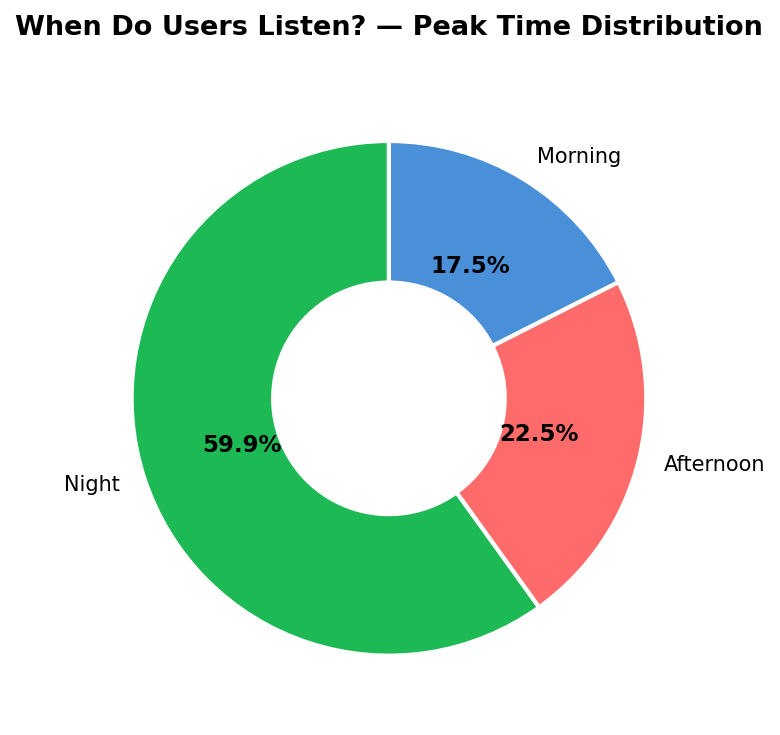

✅ Saved chart1_listening_time.png


In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
time_counts = df['music_time_slot'].value_counts()
wedges, texts, autotexts = ax.pie(
    time_counts,
    labels=time_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2),
    colors=COLORS
)
for t in autotexts:
    t.set_fontsize(11)
    t.set_fontweight('bold')
ax.set_title('When Do Users Listen? — Peak Time Distribution',
             fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('chart1_listening_time.png', bbox_inches='tight')
plt.show()
print("✅ Saved chart1_listening_time.png")

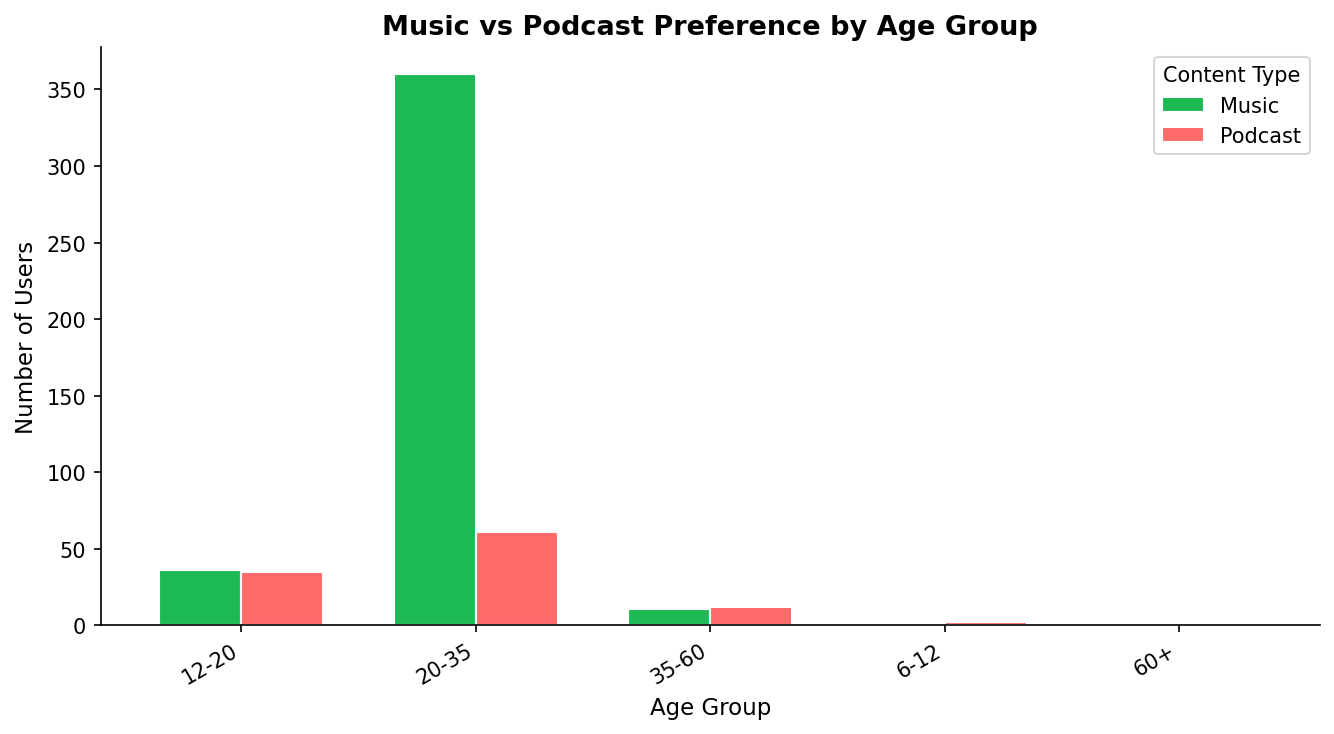

✅ Saved chart2_age_preference.png


In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
pref_age = df.groupby(['Age', 'preferred_listening_content']).size().unstack(fill_value=0)
pref_age.plot(kind='bar', ax=ax, color=[SPOTIFY_GREEN, '#FF6B6B'],
              edgecolor='white', width=0.7)
ax.set_title('Music vs Podcast Preference by Age Group',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Age Group', fontsize=11)
ax.set_ylabel('Number of Users', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend(title='Content Type', fontsize=10)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('chart2_age_preference.png', bbox_inches='tight')
plt.show()
print("✅ Saved chart2_age_preference.png")

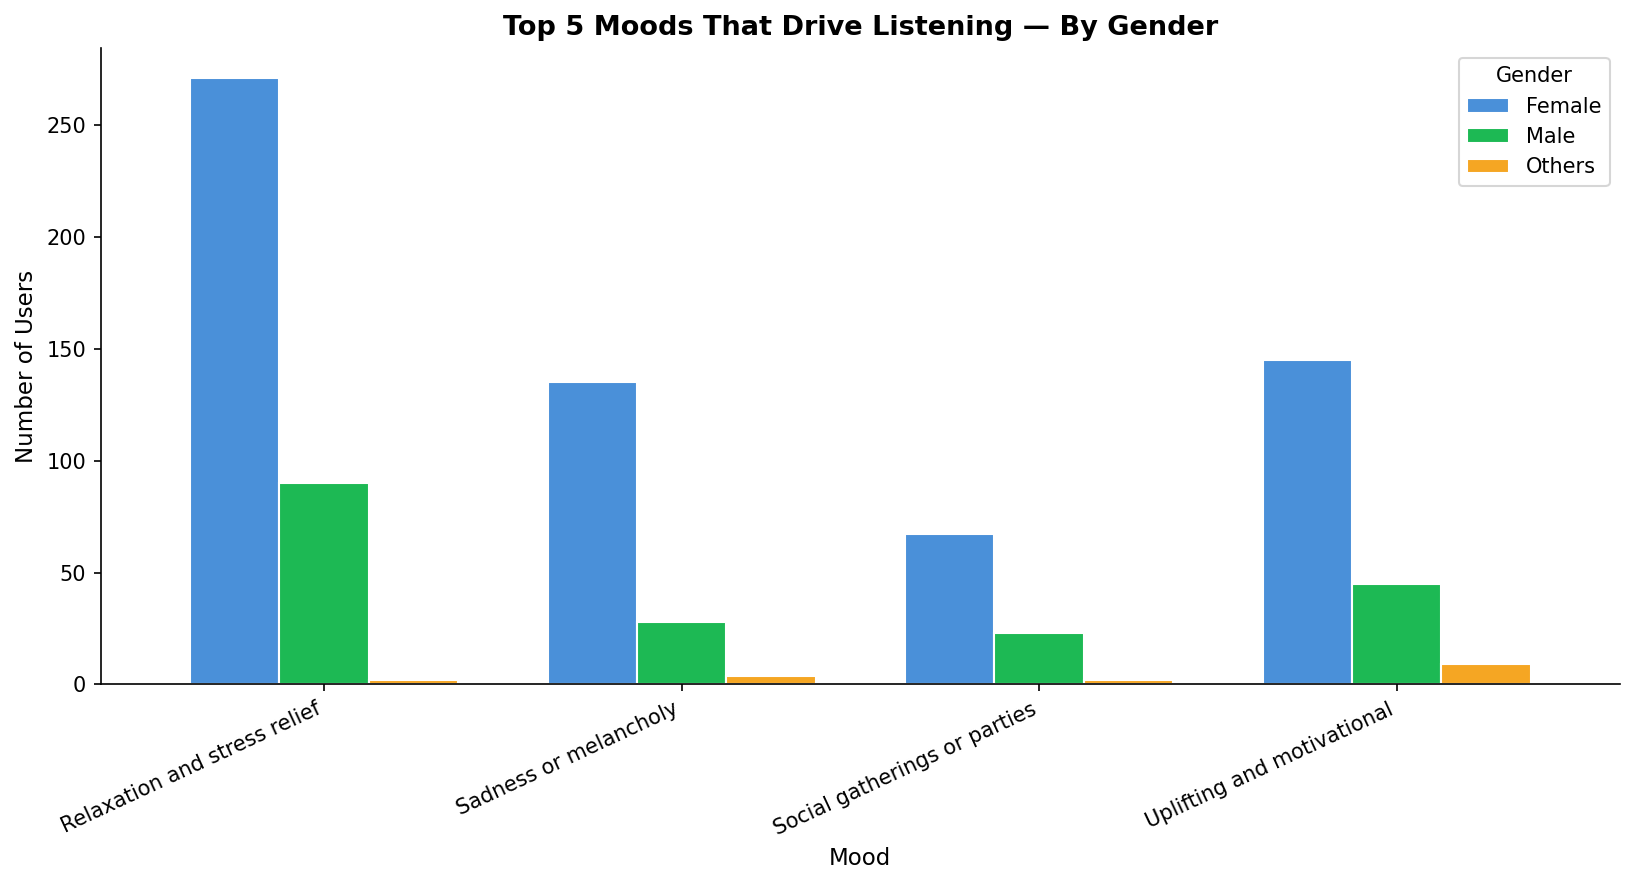

✅ Saved chart3_mood_gender.png (fixed)


In [10]:
# Fix Chart 3 — split multi-select moods into individual values
from collections import Counter

# Explode the multi-value mood column
mood_exploded = df.assign(
    mood=df['music_Influencial_mood'].str.split(',')
).explode('mood')
mood_exploded['mood'] = mood_exploded['mood'].str.strip()

# Keep only top 5 moods for clarity
top_moods = mood_exploded['mood'].value_counts().head(5).index
mood_filtered = mood_exploded[mood_exploded['mood'].isin(top_moods)]

# Plot
fig, ax = plt.subplots(figsize=(11, 6))
mood_gender = mood_filtered.groupby(['mood', 'Gender']).size().unstack(fill_value=0)
mood_gender.plot(kind='bar', ax=ax,
                 color=['#4A90D9', '#1DB954', '#F5A623'],
                 edgecolor='white', width=0.75)

ax.set_title('Top 5 Moods That Drive Listening — By Gender',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Mood', fontsize=11)
ax.set_ylabel('Number of Users', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right')
ax.legend(title='Gender', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('chart3_mood_gender.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved chart3_mood_gender.png (fixed)")

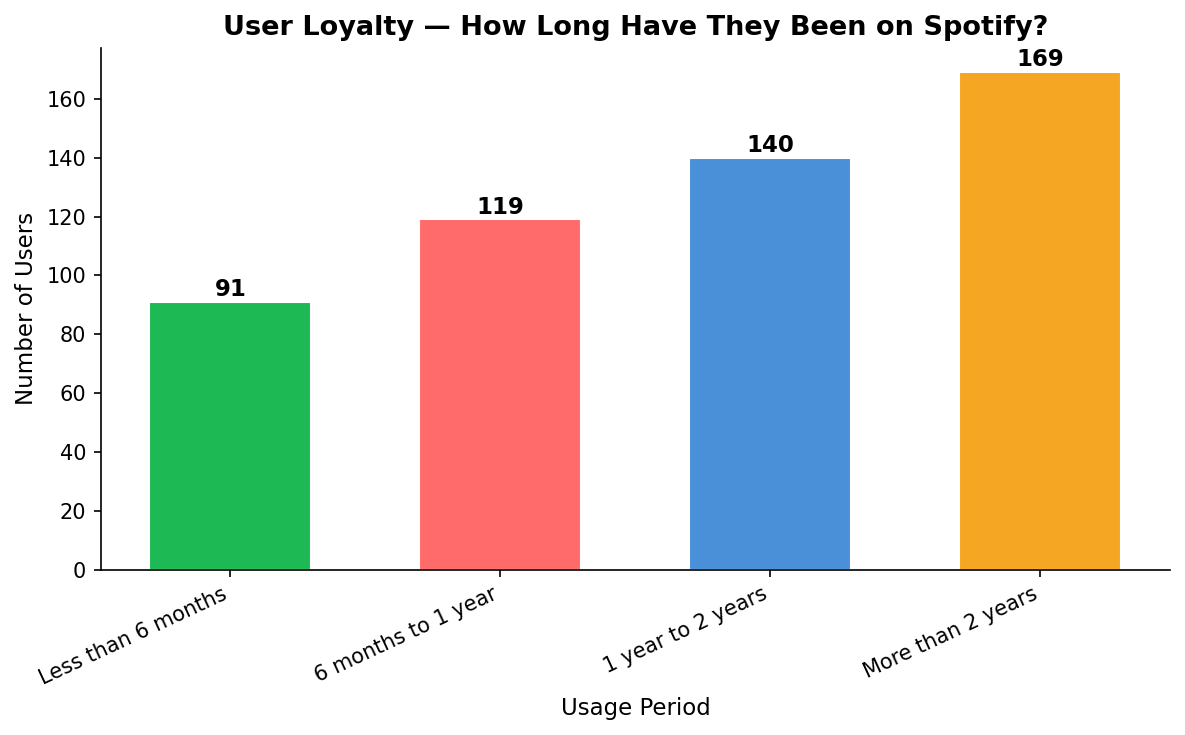

✅ Saved chart4_loyalty.png


In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
order = ['Less than 6 months','6 months to 1 year','1 year to 2 years','More than 2 years']
loyalty = df['spotify_usage_period'].value_counts().reindex(order, fill_value=0)
bars = ax.bar(loyalty.index, loyalty.values,
              color=[COLORS[i] for i in range(len(loyalty))],
              edgecolor='white', width=0.6)
for bar, val in zip(bars, loyalty.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            str(val), ha='center', fontsize=11, fontweight='bold')
ax.set_title('User Loyalty — How Long Have They Been on Spotify?',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Usage Period', fontsize=11)
ax.set_ylabel('Number of Users', fontsize=11)
ax.set_xticklabels(order, rotation=25, ha='right')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('chart4_loyalty.png', bbox_inches='tight')
plt.show()
print("✅ Saved chart4_loyalty.png")

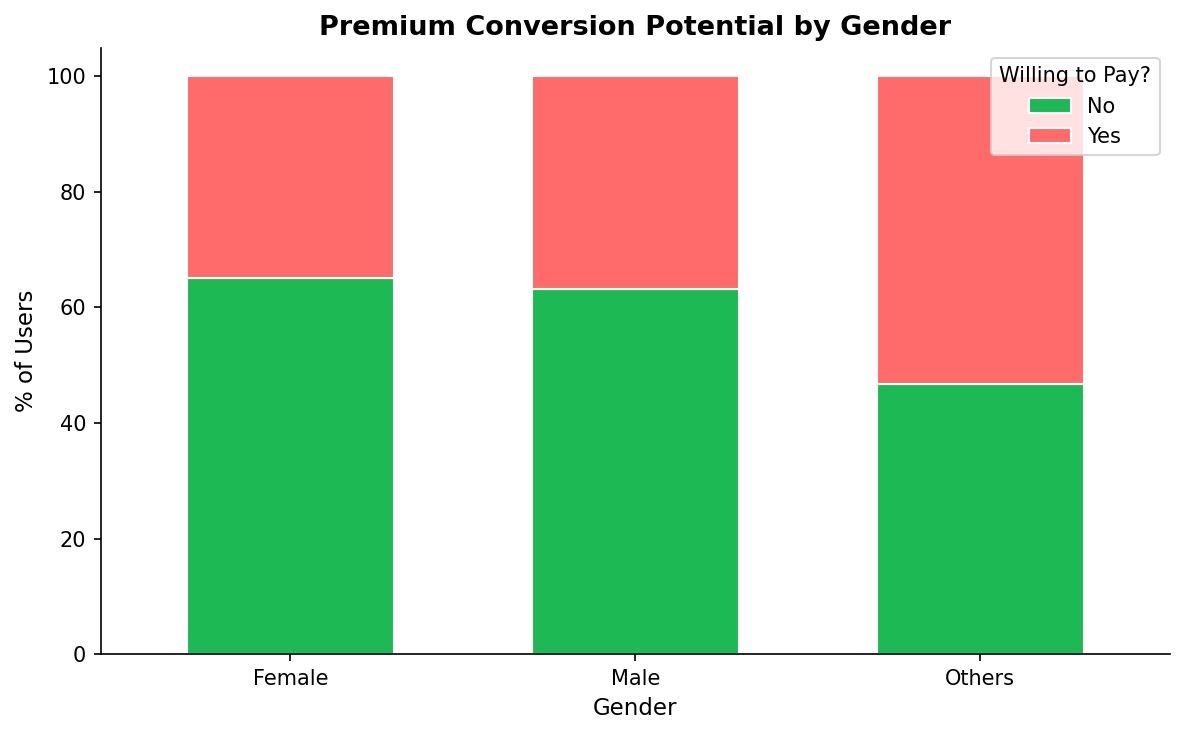

✅ Saved chart5_premium_gender.png


In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
prem_gender = df.groupby(['Gender', 'premium_sub_willingness']).size().unstack(fill_value=0)
prem_gender_pct = prem_gender.div(prem_gender.sum(axis=1), axis=0) * 100
prem_gender_pct.plot(kind='bar', stacked=True, ax=ax,
                     color=[SPOTIFY_GREEN, '#FF6B6B'],
                     edgecolor='white', width=0.6)
ax.set_title('Premium Conversion Potential by Gender',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Gender', fontsize=11)
ax.set_ylabel('% of Users', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Willing to Pay?', fontsize=10)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('chart5_premium_gender.png', bbox_inches='tight')
plt.show()
print("✅ Saved chart5_premium_gender.png")

In [13]:
from google.colab import files
df.to_csv('spotify_cleaned.csv', index=False)
files.download('spotify_cleaned.csv')
print("✅ Downloaded — check your browser downloads folder")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded — check your browser downloads folder
